## Моделирование эксперимента N₂–N₂

In [3]:
from pathlib import Path
from io import StringIO
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

from particles import N2
from k_VV import k_vv_fhofer


In [4]:
from vv_modeling import (
    ModelingConfig,
    ModelingBatch,
    k_lookup,
)

batch = ModelingBatch([
    ModelingConfig(
        name= "FHO-FR reg baseline",
        particle_a = "N2",
        particle_b = "N2",
        experiment_key=("N2", "N2", 760),
        kinetics = "regression",
        rate_multiplier = 1,

        # физика
        T  = 300.0,
        v_max = 6,
        n_total = 2.45e19,
        f_v0 = 0.63,
        f_v1 = 0.37,

        # интегрирование
        t_end_s = 12e-6,
        n_time = 600,

        # диффузия
        diffusion_method = "analytic_factor",
        sigma_pump_cm = 46e-4,
        sigma_probe_cm = 46e-4,
        d_ref = 0.25,
        p_torr = 760.0,

        # сетка method of lines
        r_max_cm = 200e-4,
        n_r = 80,
    ),
    ModelingConfig(
        name= "FHO-FR reg 2",
        particle_a = "N2",
        particle_b = "N2",
        experiment_key=("N2", "N2", 760),
        kinetics = "regression",
        rate_multiplier = 1,

        # физика
        T  = 300.0,
        v_max = 6,
        n_total = 2.45e19,
        f_v0 = 0.63,
        f_v1 = 0.37,

        # интегрирование
        t_end_s = 12e-6,
        n_time = 600,

        # диффузия
        diffusion_method = "analytic_factor",
        sigma_pump_cm = 46e-4,
        sigma_probe_cm = 46e-4,
        d_ref = 0.2,
        p_torr = 760.0,

        # сетка method of lines
        r_max_cm = 200e-4,
        n_r = 80,
    )
])

batch.run_all(max_workers=1)  # параллельно (parallel=True по умолчанию)

from vv_plotting import completed_run_labels
print("done:", ", ".join(completed_run_labels(batch)))





k_VV: N2_N2_regression_coefs.csv (72 переходов)
Предупреждение: /Users/andrey/projects/fho_gen/FHO_FR_VV/experiments/N2_N2/760/dots/exp760v6.csv не найден
Предупреждение: /Users/andrey/projects/fho_gen/FHO_FR_VV/experiments/N2_N2/760/fho/fho760v6.csv не найден
k_VV: N2_N2_regression_coefs.csv (72 переходов)
  готово: FHO-FR reg baseline::analytic_factor
Предупреждение: /Users/andrey/projects/fho_gen/FHO_FR_VV/experiments/N2_N2/760/dots/exp760v6.csv не найден
Предупреждение: /Users/andrey/projects/fho_gen/FHO_FR_VV/experiments/N2_N2/760/fho/fho760v6.csv не найден
  готово: FHO-FR reg 2::analytic_factor
done: FHO-FR reg baseline, FHO-FR reg 2


На графике: FHO-FR reg baseline, FHO-FR reg 2


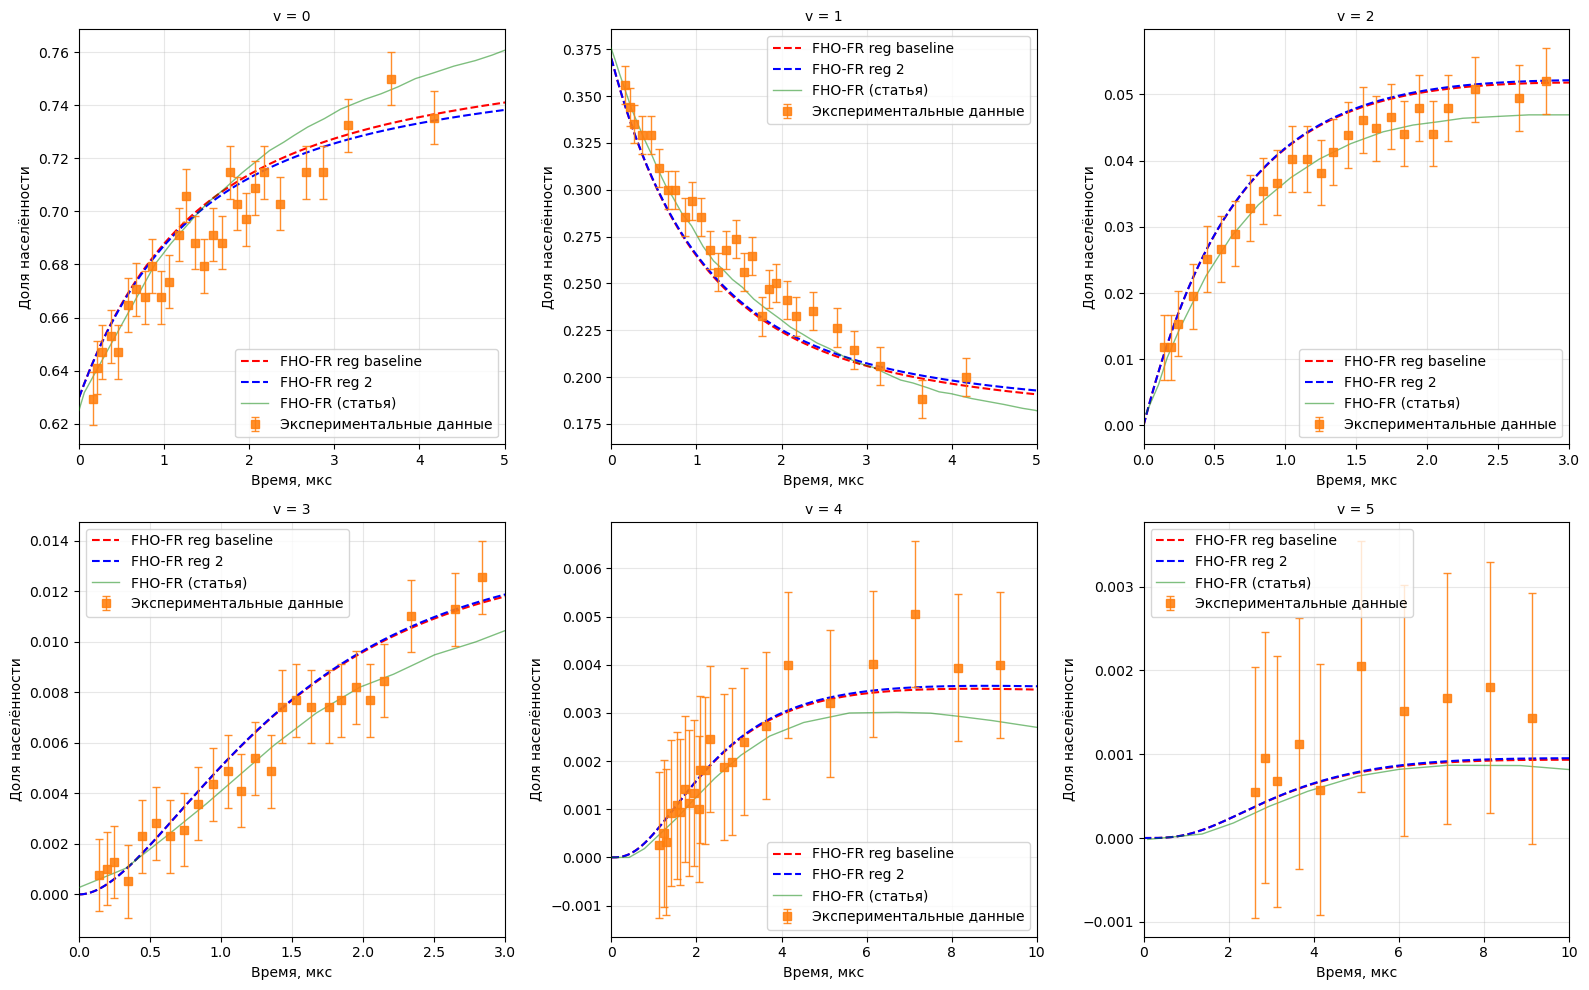

In [5]:
import matplotlib.pyplot as plt

from vv_plotting import (
    PopulationPlotConfig,
    plot_population_grid,
    completed_run_labels,
)

PLOT = PopulationPlotConfig(
    diffusion_per_run=True,
)

PLOT_RUNS = None

print("На графике:", ", ".join(completed_run_labels(batch, PLOT_RUNS)))

fig, axes = plot_population_grid(
    batch,
    runs=PLOT_RUNS,
    plot_cfg=PLOT,
)
plt.show()



Данные эксперимента: `batch.run_at(0).exp_data`, статья FHO: `batch.run_at(0).exp_mod_data`.


## Сравнение k_VV FHO-FR из статьи c k_VV из расчетов

In [6]:
# Сравнение k_VV (статья) с k_vv_mm: i1=v, f1=v−1, i2=0, f2=1 (параллельно по процессам)
import os
from functools import partial
import numpy as np
import matplotlib.pyplot as plt

from concurrent.futures import ProcessPoolExecutor

from k_VV import k_vv_mm_for_v
from experiments import get_experiment

# x_FHO_FR_VV_O2_exp_art = [0.9938208032955717, 1.8949536560247169, 2.981462409886715, 3.98043254376931, 5, 5.988671472708548, 6.9876416065911435, 7.981462409886715, 8.98043254376931, 9.974253347064883]
# y_FHO_FR_VV_O2_exp_art = [1.774128673481946e-14, 3.2878708489951796e-14, 4.271514327281122e-14, 4.646412110697944e-14, 4.588862098611196e-14, 4.153395113650955e-14, 3.576437244658811e-14, 2.911660472634801e-14, 2.3410901225667054e-14, 1.7907899768128867e-14]

_exp = get_experiment("N2", "N2", 760)
x_FHO_FR_VV_N2_exp_art, y_FHO_FR_VV_N2_exp_art = _exp["k_vv_article"]

T_N2_VV_plot = 300
v_int = np.arange(1, len(y_FHO_FR_VV_N2_exp_art) + 1, dtype=int)
_worker_n2 = partial(k_vv_mm_for_v, 'N2', 'N2', T=T_N2_VV_plot)

max_workers_n2 = min(len(v_int), os.cpu_count() or 8)
with ProcessPoolExecutor(max_workers=max_workers_n2) as ex:
    k_from_mm = np.array(list(ex.map(_worker_n2, v_int.tolist(), chunksize=1)))

k_VV: N2_N2_regression_coefs.csv (72 переходов)


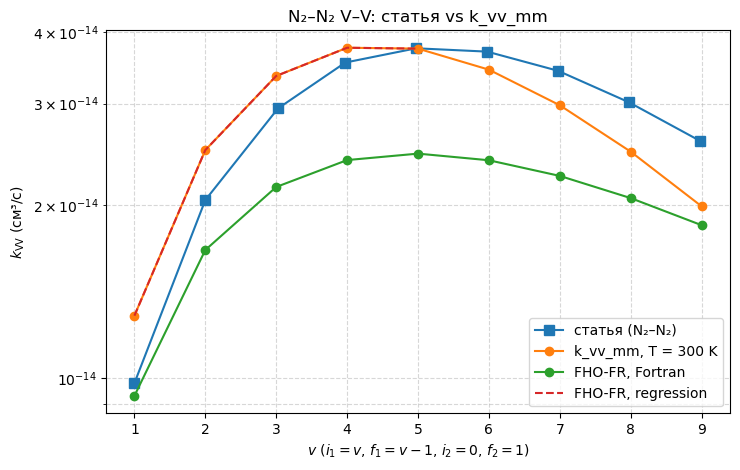

v 1 k_vv_mm 1.2836770680237246e-14 k_vv_fortran 9.310261957504696e-09
v 2 k_vv_mm 2.4913425246611576e-14 k_vv_fortran 1.6697405679581678e-08
v 3 k_vv_mm 3.351875188207312e-14 k_vv_fortran 2.1490419080865978e-08
v 4 k_vv_mm 3.7526905807416555e-14 k_vv_fortran 2.3934263352280065e-08
v 5 k_vv_mm 3.7392918236210524e-14 k_vv_fortran 2.456062034299939e-08
v 6 k_vv_mm 3.437253954083191e-14 k_vv_fortran 2.391639955801123e-08
v 7 k_vv_mm 2.980626033268739e-14 k_vv_fortran 2.2463180487656388e-08
v 8 k_vv_mm 2.475040583914413e-14 k_vv_fortran 2.055396517474158e-08
v 9 k_vv_mm 1.988825538408366e-14 k_vv_fortran 1.844158308718254e-08


In [7]:
from particles import N2

_run = batch.run_at(0)
coeffs = _run.config.coeffs
T_vv = _run.config.T

k_vv_fortran_N2 = np.array([
    k_vv_fhofer(N2, N2, i1=1, i2=v - 1, f1=0, f2=v, T=T_vv) for v in range(1, 10)
])
k_reg_N2 = np.array([
    k_lookup(coeffs, i1=1, i2=v - 1, f1=0, f2=v, T=T_vv) for v in range(1, 6)
])

k_mm_plot = np.where(k_from_mm > 0, k_from_mm, np.nan)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(
    x_FHO_FR_VV_N2_exp_art,
    y_FHO_FR_VV_N2_exp_art,
    "s-",
    ms=7,
    label="статья (N₂–N₂)",
)
ax.plot(
    v_int,
    k_mm_plot,
    "o-",
    ms=6,
    label=f"k_vv_mm, T = {T_N2_VV_plot} K",
)
ax.plot(v_int, k_vv_fortran_N2, 'o-', label='FHO-FR, Fortran')
ax.plot(range(1, 6), k_reg_N2, '--', label=f'FHO-FR, regression')
ax.set_yscale("log")
# ax.set_ylim(1e-14, 1e-12)
ax.set_xlabel(r"$v$ ($i_1=v$, $f_1=v-1$, $i_2=0$, $f_2=1$)")
ax.set_ylabel(r"$k_{\mathrm{VV}}$ (см³/с)")
ax.set_title("N₂–N₂ V–V: статья vs k_vv_mm")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

for v, k, k_fortran in zip(v_int, k_from_mm, k_vv_fortran_N2):
    print("v", int(v), "k_vv_mm", k, "k_vv_fortran", k_fortran * 1e6)


## Сравнение k_VV из расчетов, оригинальной статьи Адамовича для MM, статьи про эксперимент для N2-N2

In [8]:
import os
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
from concurrent.futures import ProcessPoolExecutor

from k_VV import k_vv_mm_for_v
from experiments import get_experiment


calc_levels = [i for i in range(1, 10)]
T_calc = 300
_worker = partial(k_vv_mm_for_v, 'N2', 'N2', T=T_calc)

max_workers = min(len(calc_levels), os.cpu_count() or 8)
with ProcessPoolExecutor(max_workers=max_workers) as ex:
    k_vals = list(ex.map(_worker, calc_levels, chunksize=1))

for v, k in zip(calc_levels, k_vals):
    print("v", v, "k_vv_mm", k)
k_vv = np.array(k_vals)

_fho = get_experiment("N2", "N2", 760)
x_fho_fr_exp_N2, y_fho_fr_exp_N2 = _fho["k_vv_fho_article"]

x_FHO_FR_k_VV_MM_Adamovich_article, y_FHO_FR_k_VV_MM_Adamovich_article = _fho["k_vv_adamovich_mm"]


v 1 k_vv_mm 1.2836770680237246e-14
v 2 k_vv_mm 2.4913425246611576e-14
v 3 k_vv_mm 3.351875188207312e-14
v 4 k_vv_mm 3.7526905807416555e-14
v 5 k_vv_mm 3.7392918236210524e-14
v 6 k_vv_mm 3.437253954083191e-14
v 7 k_vv_mm 2.980626033268739e-14
v 8 k_vv_mm 2.475040583914413e-14
v 9 k_vv_mm 1.988825538408366e-14


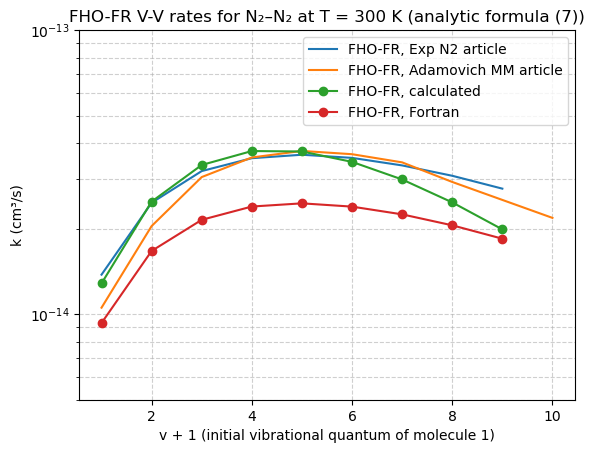

In [9]:
_run = batch.run_at(0)
T_vv = _run.config.T
k_vv_fortran = np.array([k_vv_fhofer(N2, N2, i1=1, i2=v - 1, f1=0, f2=v, T=T_vv) for v in range(1, 10)])

plt.plot(x_fho_fr_exp_N2, y_fho_fr_exp_N2, label='FHO-FR, Exp N2 article')
plt.plot(x_FHO_FR_k_VV_MM_Adamovich_article, y_FHO_FR_k_VV_MM_Adamovich_article, label='FHO-FR, Adamovich MM article')
plt.plot(calc_levels, k_vv, 'o-', label='FHO-FR, calculated')
plt.plot(calc_levels, k_vv_fortran, 'o-', label='FHO-FR, Fortran')
plt.yscale('log')
plt.xlabel('v + 1 (initial vibrational quantum of molecule 1)')
plt.ylabel('k (cm³/s)')
plt.ylim(5e-15, 1e-13)
plt.title('FHO-FR V-V rates for N₂–N₂ at T = 300 K (analytic formula (7))')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend()
plt.show()
